In [1]:
import utils
import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
(train_x, train_y), (test_x, test_y) = utils.read_stratified_data(columns=("model", "lighting"))

datasett/Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg /data/upload/3/c94577a6-Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg
datasett/kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png /data/upload/3/5e846c95-kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png
datasett/black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg /data/upload/3/e82f4a47-black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg
datasett/275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg /data/upload/3/bb413a1b-275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg


(3684, 300, 300, 3)
(3684, 4)
(651, 300, 300, 3)
(651, 4)
                  color lighting      model       year
420               White    Light  Other car        NaN
939   Light gray/Silver   Medium          3  2017–2023
2235              White    Light          S  2016–2020
70      Black/Dark gray    Light          3  2017–2023
351     Black/Dark gray   Medium          Y  2020–2024
...                 ...      ...        ...        ...
477     Black/Dark gray    Light  Other car        NaN
1597    Black/Dark gray   Medium          Y    2025-nå
1622                Red    Light  Other car        NaN
975                 Red    Light  Other car        NaN
1725               Blue    Light  Other car        NaN

[3684 rows x 4 columns]


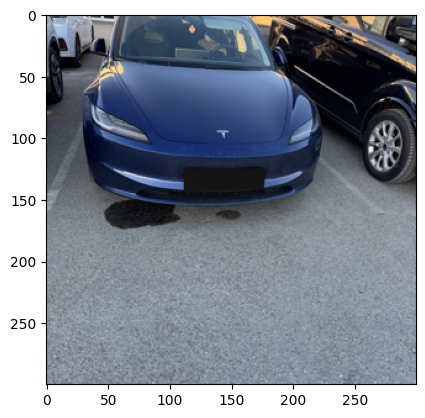

In [3]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

i = 93
print(train_y)
plt.imshow(train_x[i])
plt.show()

In [4]:
i = 0

color       Light gray/Silver
lighting                Light
model               Other car
year                      NaN
Name: 1346, dtype: str


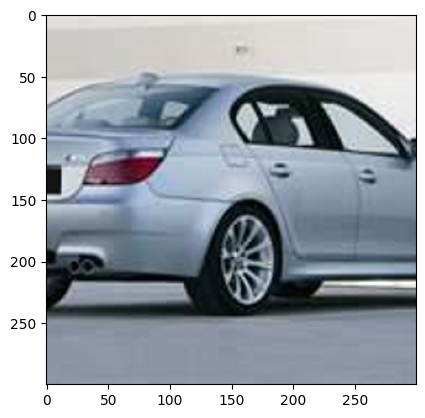

In [69]:
print(train_y.iloc[i])
plt.imshow(train_x[i])
plt.show()
i += 1

In [ ]:
train_y_new = train_y["model"]

def t(x):
    if x == 'Other car':
        return 1
    return 0

vt = np.vectorize(t)

train_y_new = vt(train_y_new)

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)
    return keras.Model(inputs, outputs) 

functional_model = make_model(train_x[0].shape, 1)

epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

functional_model.fit(
    train_x,
    train_y_new,
    epochs=epochs,
)

[1 0 0 1 1 0 1 0 1 1]
Epoch 1/5


I0000 00:00:1771448358.787015   23777 service.cc:148] XLA service 0x77cd800041e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771448358.788212   23777 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-02-18 21:59:18.878331: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771448359.084607   23777 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/114 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4298 - loss: 0.8960

I0000 00:00:1771448364.243189   23777 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


114/114 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.7022 - loss: 0.5735
Epoch 2/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8165 - loss: 0.4232
Epoch 3/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8620 - loss: 0.3289
Epoch 4/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9011 - loss: 0.2542
Epoch 5/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9361 - loss: 0.1834


In [ ]:
test_y_new = test_y["model"]
test_y_new = vt(test_y_new)

functional_model.evaluate(test_x, test_y_new)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8247 - loss: 0.4562


[0.45621082186698914, 0.8247261643409729]

```
['Dark-Other car--Orange', 'Light-S-2021–nå-Light gray/Silver']
Mangler orange bil, mørk og Nyeste model S grå/sølv i lys for å kunne stratifisere på 'color'
Har Ekskludert nyeste model X for å kunne stratifisere på 'year'
```

In [7]:
print(train_x.shape)
print(train_y.shape)

print(test_x.shape)
print(test_y.shape)

(3629, 300, 300, 3)
(3629, 4)
(640, 300, 300, 3)
(640, 4)


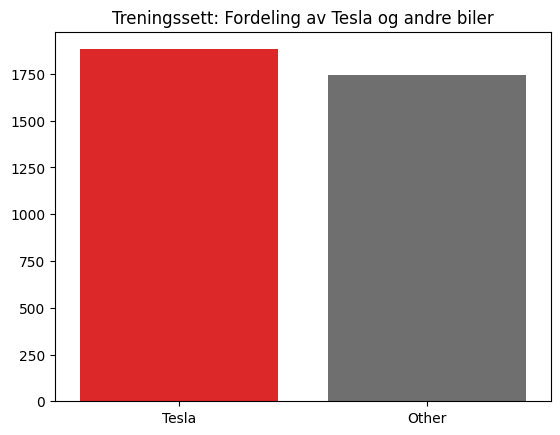

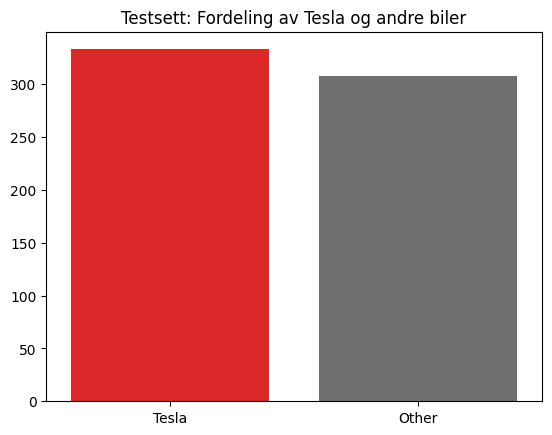

In [98]:
df = train_y
other = 'Other car'

names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Treningssett: Fordeling av Tesla og andre biler')
plt.show()

df = test_y
names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Testsett: Fordeling av Tesla og andre biler')
plt.show()

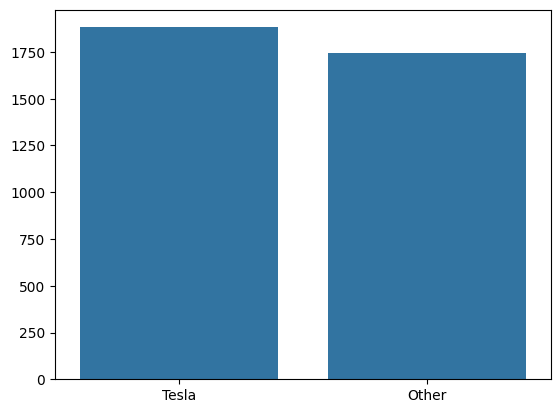

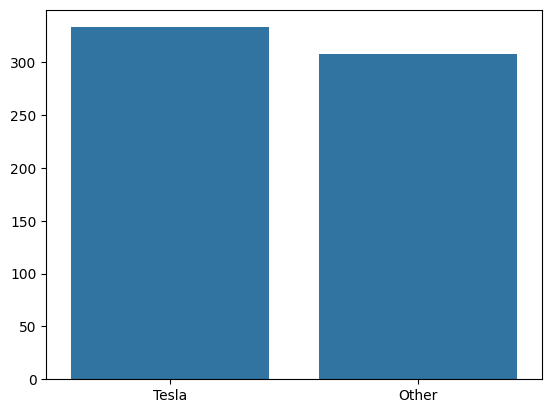

In [ ]:
df = train_y
tesla = df[df['model'] != other]
others = df[df['model'] == other]


sns.barplot(data={'Tesla':len(tesla), 'Other': len(others)})
plt.show()

df = test_y
tesla = df[df['model'] != other]
others = df[df['model'] == other]

sns.barplot(data={'Tesla':len(tesla), 'Other': len(others)})
plt.show()

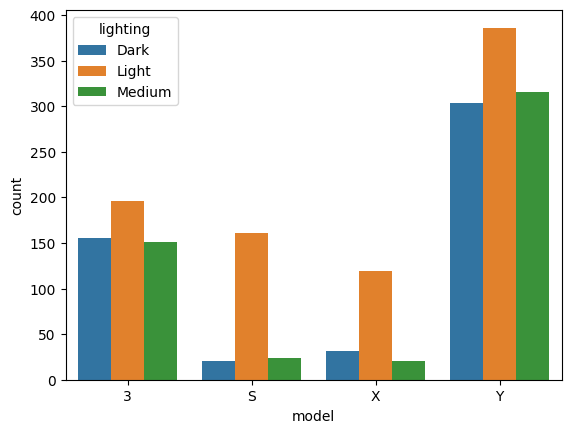

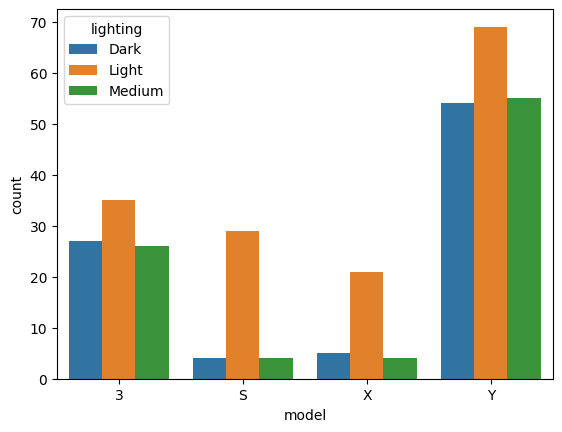

In [114]:
df = train_y
tesla = df[df['model'] != other].sort_values(by="model").sort_values(by="lighting", kind='stable')

sns.countplot(data=tesla, x="model", hue="lighting")
plt.show()
df = test_y
tesla = df[df['model'] != other].sort_values(by="model").sort_values(by="lighting", kind='stable')


sns.countplot(data=tesla, x="model", hue="lighting")
plt.show()

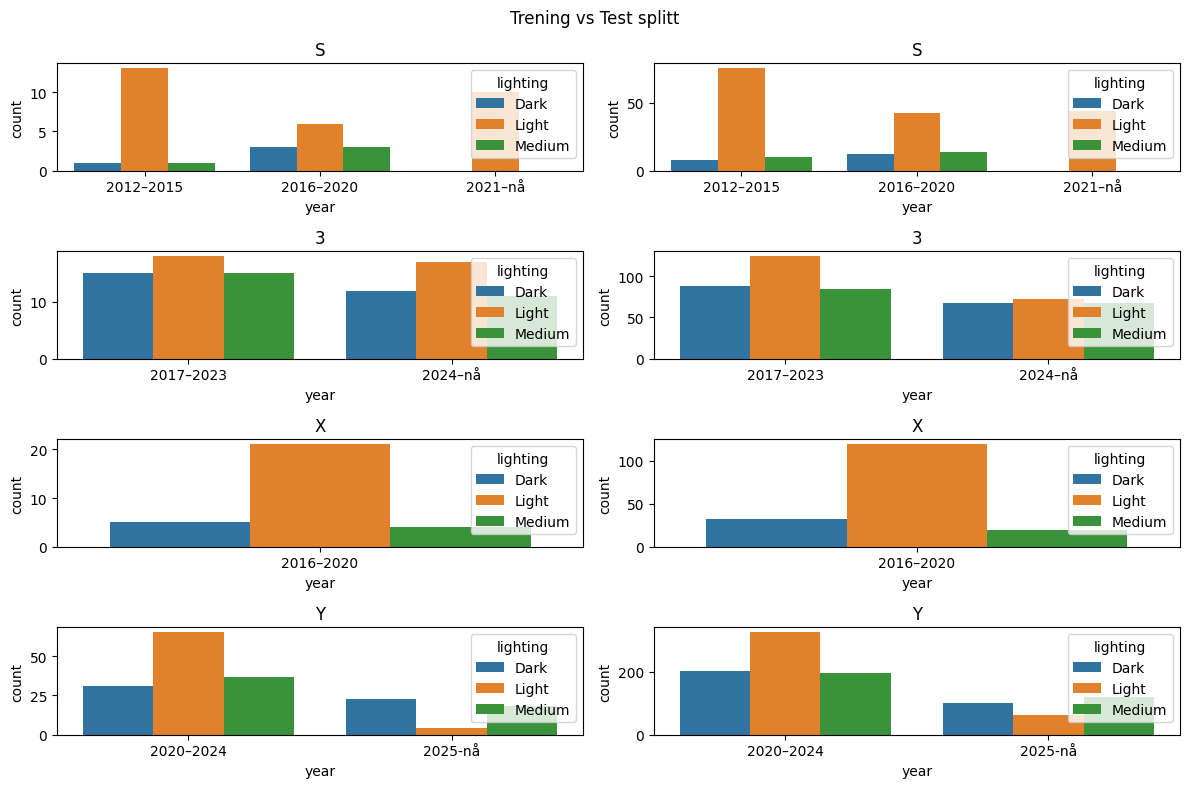

In [113]:
train_y_split = [
    train_y[train_y['model'] == 'S'].sort_values('year').sort_values('lighting', kind='stable'),
    train_y[train_y['model'] == '3'].sort_values('year').sort_values('lighting', kind='stable'),
    train_y[train_y['model'] == 'X'].sort_values('year').sort_values('lighting', kind='stable'),
    train_y[train_y['model'] == 'Y'].sort_values('year').sort_values('lighting', kind='stable')
]
test_y_split = [
    test_y[test_y['model'] == 'S'].sort_values('year').sort_values('lighting', kind='stable'),
    test_y[test_y['model'] == '3'].sort_values('year').sort_values('lighting', kind='stable'),
    test_y[test_y['model'] == 'X'].sort_values('year').sort_values('lighting', kind='stable'),
    test_y[test_y['model'] == 'Y'].sort_values('year').sort_values('lighting', kind='stable')
]

models = ["S", "3", "X", "Y"]
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
fig.suptitle(f'Trening vs Test splitt')
for i in range(0,2):
    for j in range(0,2):
        sns.countplot(x='year', data=train_y_split[i*2 + j], ax=axes[i*2+j,1], hue='lighting')
        axes[i*2+j,0].title.set_text(models[i*2 + j])
        sns.countplot(x='year', data=test_y_split[i*2 + j], ax=axes[i*2+j,0], hue='lighting')
        axes[i*2+j,1].title.set_text(models[i*2 + j])

plt.tight_layout()
plt.show()

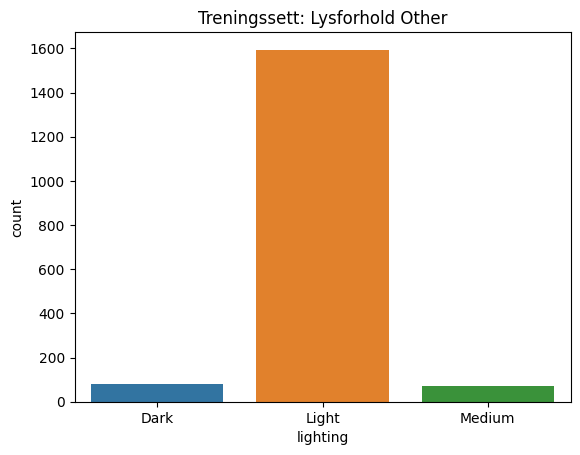

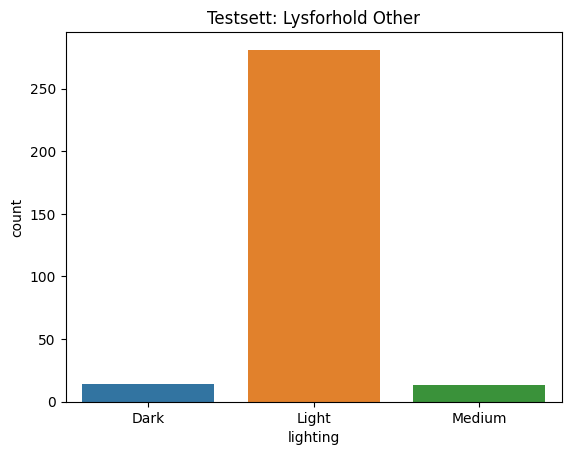

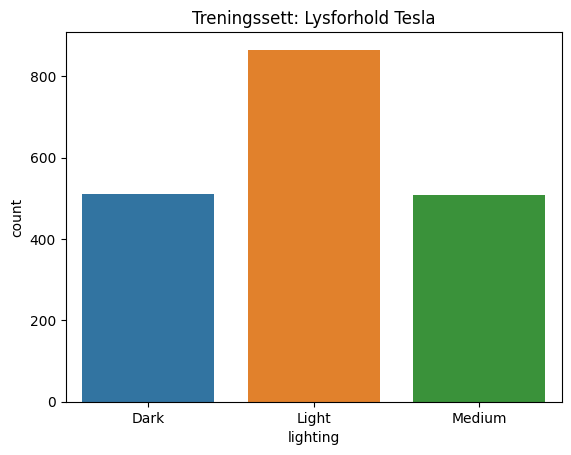

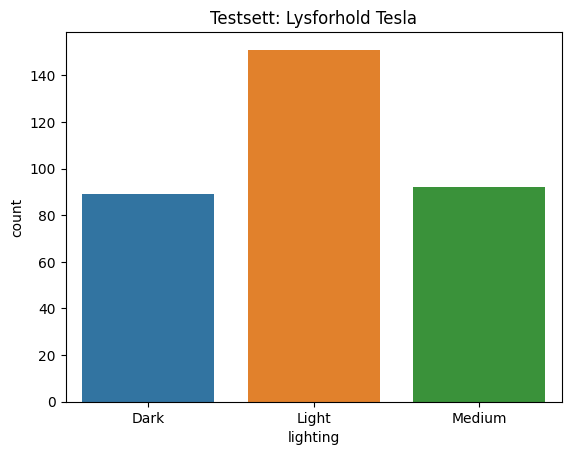

In [11]:
df = train_y[train_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Other')
plt.show()

df = test_y[test_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Other')
plt.show()

df = train_y[train_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()

df = test_y[test_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Tesla')
plt.show()